In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

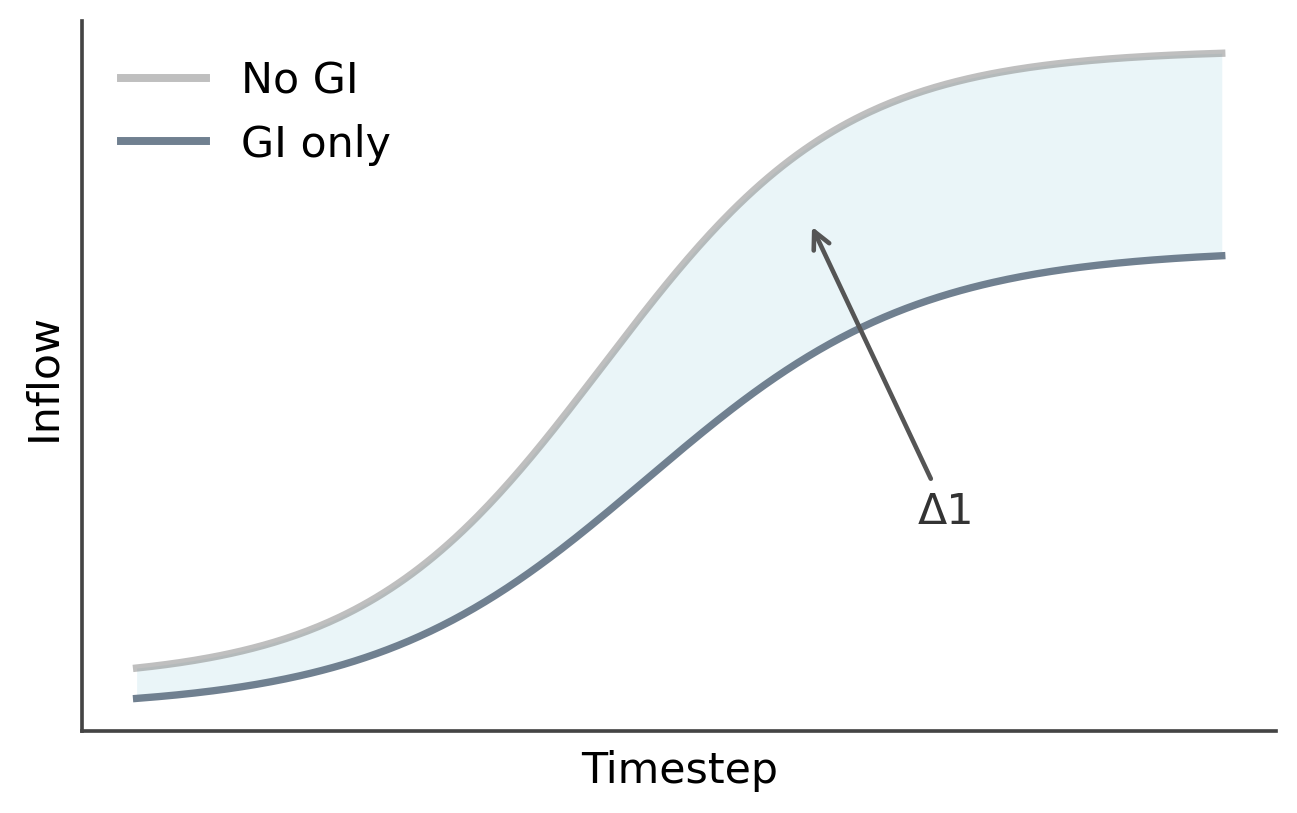

In [2]:
rng = np.random.default_rng(42)

t = np.linspace(0, 1, 300)

def smooth_cumsum(t, k=8, mid=0.45, scale=1.0, stepiness=0.08):
    # S shape
    s = 1 / (1 + np.exp(-k*(t - mid)))
    s = (s - s.min()) / (s.max() - s.min())
    y = (0.15 + 0.85*s) * (0.9 + 0.1)
    return scale * y

y_no_gi = smooth_cumsum(t, k=9, mid=0.43, scale=1.00)
y_gi    = smooth_cumsum(t, k=8, mid=0.47, scale=0.72)

color_no = "grey"   
color_gi = "slategrey"   
fill_col = "lightblue"  
alpha_fill = 0.25

plt.figure(figsize=(6, 3.8), dpi=220)

plt.fill_between(t, y_no_gi, y_gi, where=(y_no_gi>=y_gi),
                 color=fill_col, alpha=alpha_fill, linewidth=0)

line_no = plt.plot(t, y_no_gi, color=color_no, lw=2.4, label="No GI", alpha = 0.5)[0]
line_gi = plt.plot(t, y_gi,    color=color_gi, lw=2.4, label="GI only")[0]

plt.xlabel("Timestep", labelpad=6, fontsize=14)
plt.ylabel("Inflow", labelpad=6, fontsize=14)

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_color("#444")
ax.spines["bottom"].set_color("#444")
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

ax.annotate("Δ1", xy=(0.62, (y_no_gi[200]+y_gi[200])/2),
            xytext=(0.72, 0.35),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5),
            color="#333", fontsize=14)

leg = plt.legend(frameon=False, loc="upper left", fontsize=14)
for h in leg.legend_handles:
    h.set_linewidth(2.6)

plt.tight_layout()

plt.savefig("sample_delta1.png", dpi=300, bbox_inches="tight")
plt.show()

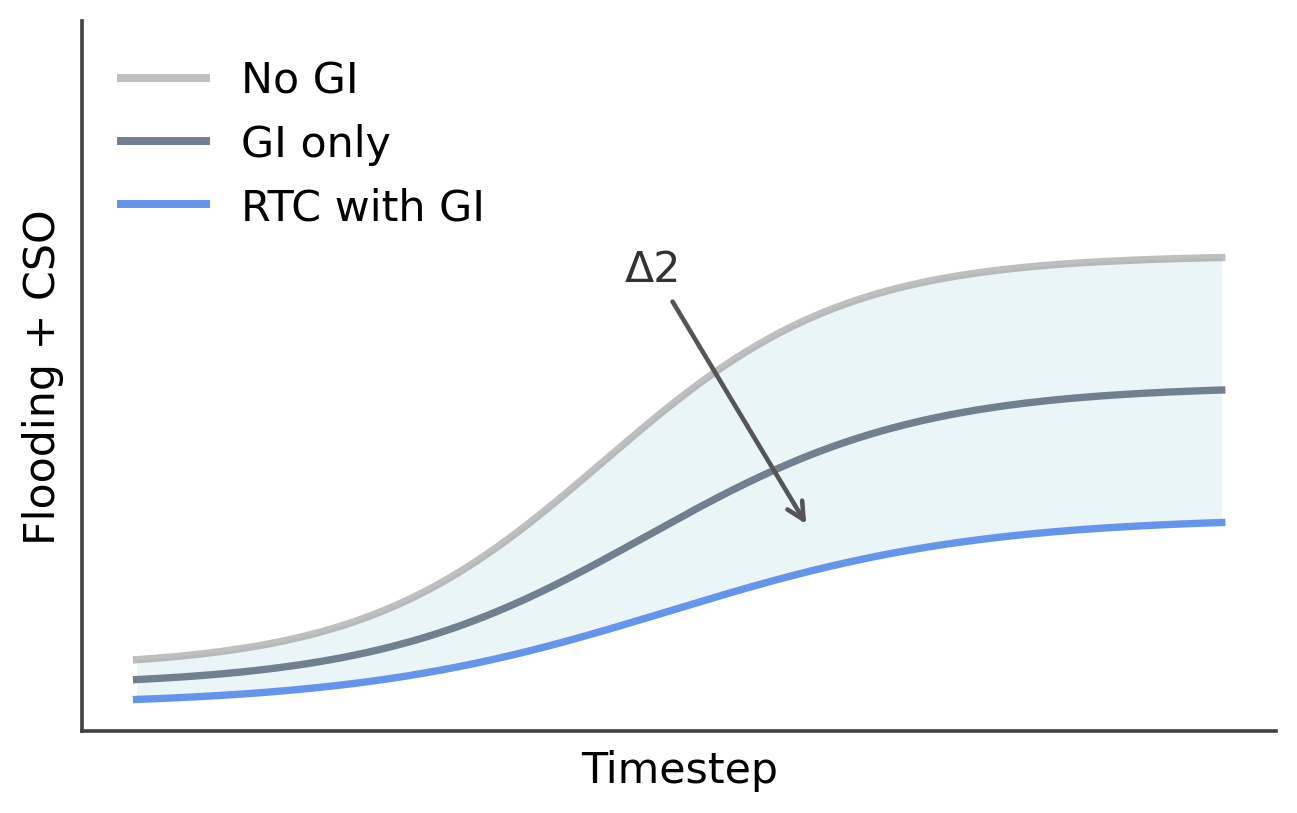

In [3]:
rng = np.random.default_rng(42)

t = np.linspace(0, 1, 300)

def smooth_cumsum(t, k=8, mid=0.45, scale=1.0, stepiness=0.08):
    # S shape
    s = 1 / (1 + np.exp(-k*(t - mid)))
    s = (s - s.min()) / (s.max() - s.min())
    y = (0.15 + 0.85*s) * (0.9 + 0.1)
    return scale * y

y_no_gi = smooth_cumsum(t, k=9, mid=0.43, scale=1.00)
y_gi    = smooth_cumsum(t, k=8, mid=0.47, scale=0.72)
y_rtc    = smooth_cumsum(t, k=7, mid=0.49, scale=0.44)

color_no = "grey"   
color_gi = "slategrey"  
color_rtc = "cornflowerblue"
fill_col = "lightblue"   
alpha_fill = 0.25

plt.figure(figsize=(6, 3.8), dpi=220)

plt.fill_between(t, y_no_gi, y_rtc, where=(y_no_gi>=y_rtc),
                 color=fill_col, alpha=alpha_fill, linewidth=0)

line_no = plt.plot(t, y_no_gi, color=color_no, lw=2.4, label="No GI", alpha = 0.5)[0]
line_gi = plt.plot(t, y_gi,    color=color_gi, lw=2.4, label="GI only")[0]
line_rtc = plt.plot(t, y_rtc,    color=color_rtc, lw=2.4, label="RTC with GI")[0]

plt.xlabel("Timestep", labelpad=6, fontsize=14)
plt.ylabel("Flooding + CSO", labelpad=6, fontsize=14)

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_color("#444")
ax.spines["bottom"].set_color("#444")
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ymax = max(y_no_gi.max(), y_gi.max())
ax.set_ylim(bottom=0, top=ymax * 1.5) 

ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

ax.annotate("Δ2", xy=(0.62, (y_no_gi[200]+y_rtc[200])/3),
            xytext=(0.45, 0.95),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5),
            color="#333", fontsize=14)

leg = plt.legend(frameon=False, loc="upper left", fontsize=14)
for h in leg.legend_handles:
    h.set_linewidth(2.6)

plt.tight_layout()

plt.savefig("sample_delta2.png", dpi=300, bbox_inches="tight")
plt.show()